Import pandas and read csv files

In [1]:
import pandas as pd

df_sales = pd.read_csv("/kaggle/input/datasets/zsebben/pharmacy-sales-tables/sales.csv", sep=";")
df_product = pd.read_csv("/kaggle/input/datasets/zsebben/pharmacy-sales-tables/product.csv", sep=";")
df_customer = pd.read_csv("/kaggle/input/datasets/zsebben/pharmacy-sales-tables/customer.csv", sep=";")


Convert the date column to datetime format in the sales table

In [2]:
print(df_sales.dtypes)  

df_sales["date"] = pd.to_datetime(df_sales["date"])

date           object
product_id     object
customer_id    object
quantity        int64
price          object
text           object
dtype: object


Cleaning the price column: fixing separators and converting to float

In [3]:
df_sales["price"] = df_sales["price"].str.replace(",", ".", regex=False)

df_sales["price"] = pd.to_numeric(df_sales["price"]) #string to float

print(df_sales.dtypes) #double check

date           datetime64[ns]
product_id             object
customer_id            object
quantity                int64
price                 float64
text                   object
dtype: object


Checking data types in the customer table and removing additional columns

In [4]:

print(df_customer.dtypes)  #datatypes ok
df_customer = df_customer[["customer_id", "company_name", "customer_type"]]  #additional columns

customer_id      object
company_name     object
customer_type    object
dtype: object


Checking data types in the product table and fixing separators before float conversion

In [5]:
print(df_product.dtypes) 

df_product["manufacturing_cost"]=df_product["manufacturing_cost"].str.replace(",", ".", regex=False)  #separator conversion
df_product["manufacturing_cost"]= pd.to_numeric(df_product["manufacturing_cost"])

print(df_product.dtypes) #double check

product_id            object
drug_name             object
form                  object
category              object
manufacturing_cost    object
dtype: object
product_id             object
drug_name              object
form                   object
category               object
manufacturing_cost    float64
dtype: object


Generating the master sales table and applying a left join between sales and customer data. Calculating revenue.

In [6]:
MASTER_SALES = df_sales.merge(df_customer, how="left", on="customer_id")

MASTER_SALES["revenue"] = MASTER_SALES["quantity"] * MASTER_SALES["price"]
print(MASTER_SALES.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           15000 non-null  datetime64[ns]
 1   product_id     7807 non-null   object        
 2   customer_id    15000 non-null  object        
 3   quantity       15000 non-null  int64         
 4   price          15000 non-null  float64       
 5   text           15000 non-null  object        
 6   company_name   15000 non-null  object        
 7   customer_type  15000 non-null  object        
 8   revenue        15000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 1.0+ MB
None


In many rows the product_id field is missing, but the ID appears inside the text.To make the dataset mergeable with the product table, I extract these IDs using a regex pattern.

In [7]:
def id_finder(MASTER_SALES):        #define formula
    pattern = r"(P\d{3,4})"  # searching for the ID pattern
    return MASTER_SALES["text"].str.extract(pattern)   # extract the pattern from the text


MASTER_SALES["product_id_from_text"] = id_finder(MASTER_SALES) 

Merging the original and extracted datas as product_id_cleaned

In [8]:
MASTER_SALES["product_id_cleaned"] = MASTER_SALES["product_id"].fillna(MASTER_SALES["product_id_from_text"])

Merging df_product

In [9]:
MASTER_SALES = MASTER_SALES.merge(  
    df_product,                  
    how="left",                    
    left_on="product_id_cleaned",    
    right_on="product_id"            
)

In [10]:
MASTER_SALES = MASTER_SALES.drop(columns=["product_id_x", "product_id_y", "product_id_from_text"])

Date to month

In [11]:
MASTER_SALES["YM"] = MASTER_SALES["date"].dt.to_period("M").dt.to_timestamp()

To analyze long‑term trends instead of noisy daily fluctuations, I aggregate total revenue at the year‑month level. This produces a clean monthly time series that can be visualized and later used for forecasting.

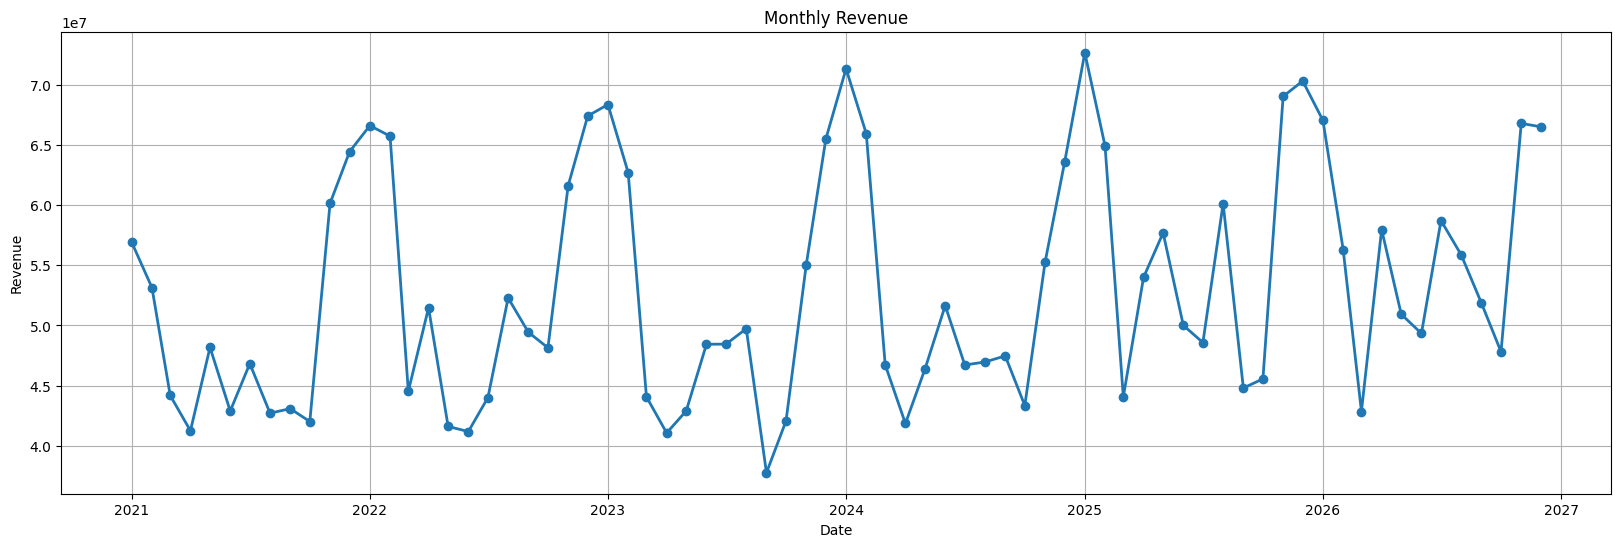

In [12]:
revenue_YM = MASTER_SALES.groupby("YM")["revenue"].sum().sort_index()

import matplotlib.pyplot as plt
plt.figure(figsize=(20,6))
plt.plot(revenue_YM.index, revenue_YM, linewidth=2, marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

Aggregating Monthly Revenue by Category

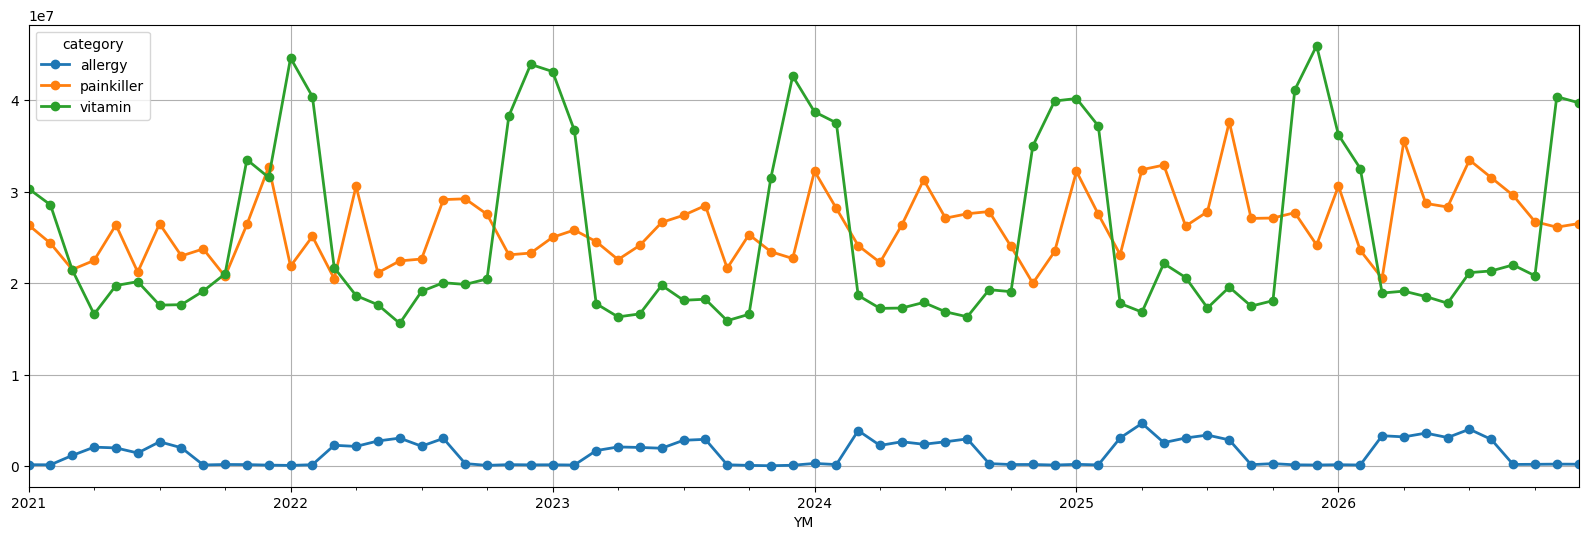

In [13]:
revenue_by_category = MASTER_SALES.groupby(["YM", "category"])["revenue"].sum()
rev_pivot = revenue_by_category.unstack("category").fillna(0)

rev_pivot.plot(figsize=(20,6), linewidth=2, marker="o")
plt.grid(True)
plt.show()

Analyzing the seasonality of the vitamin category

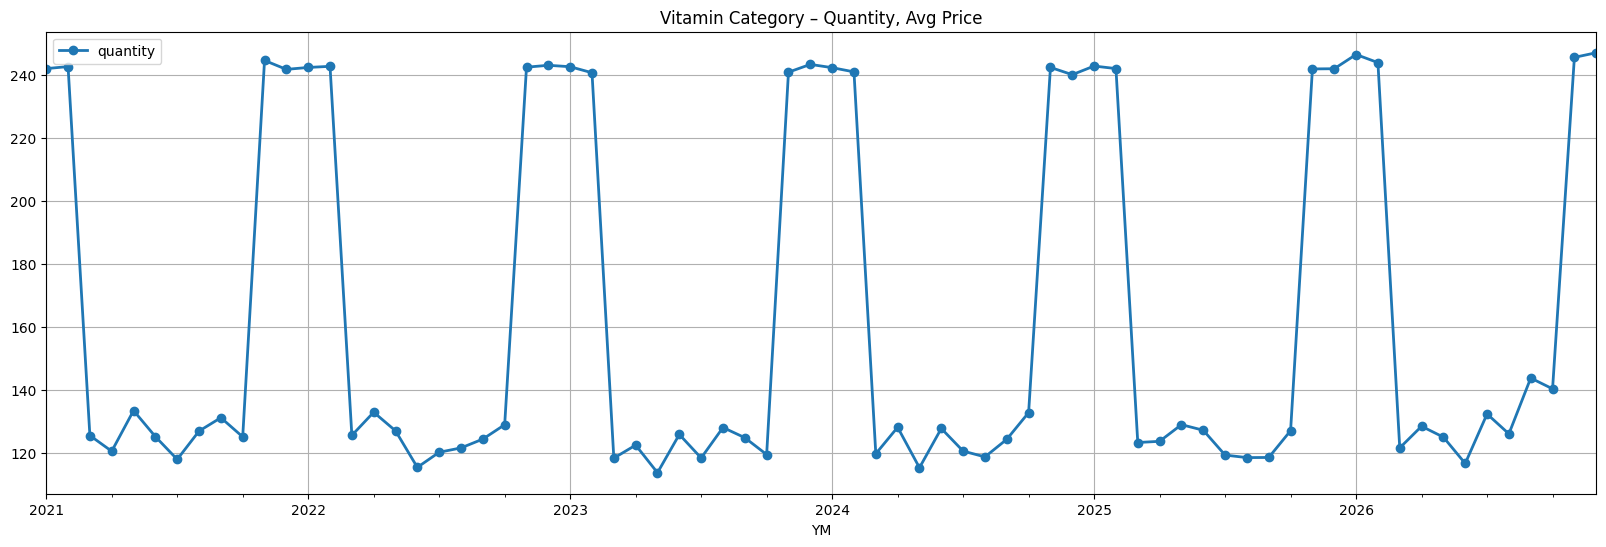

In [14]:
vitamin_df = MASTER_SALES[MASTER_SALES["category"] == "vitamin"]  #filter vitamin in category
vitamin_pivot = vitamin_df.pivot_table(
    index="YM",
    values=[ "quantity"],
    aggfunc="mean")

vitamin_pivot.plot(
    figsize=(20,6),
    linewidth=2,
    marker="o",
    title="Vitamin Category – Quantity, Avg Price"
)

plt.grid(True)
plt.show()

Forecasting Monthly Revenue with Holt–Winters.
Trend + seasonality to predict the next 12 months.

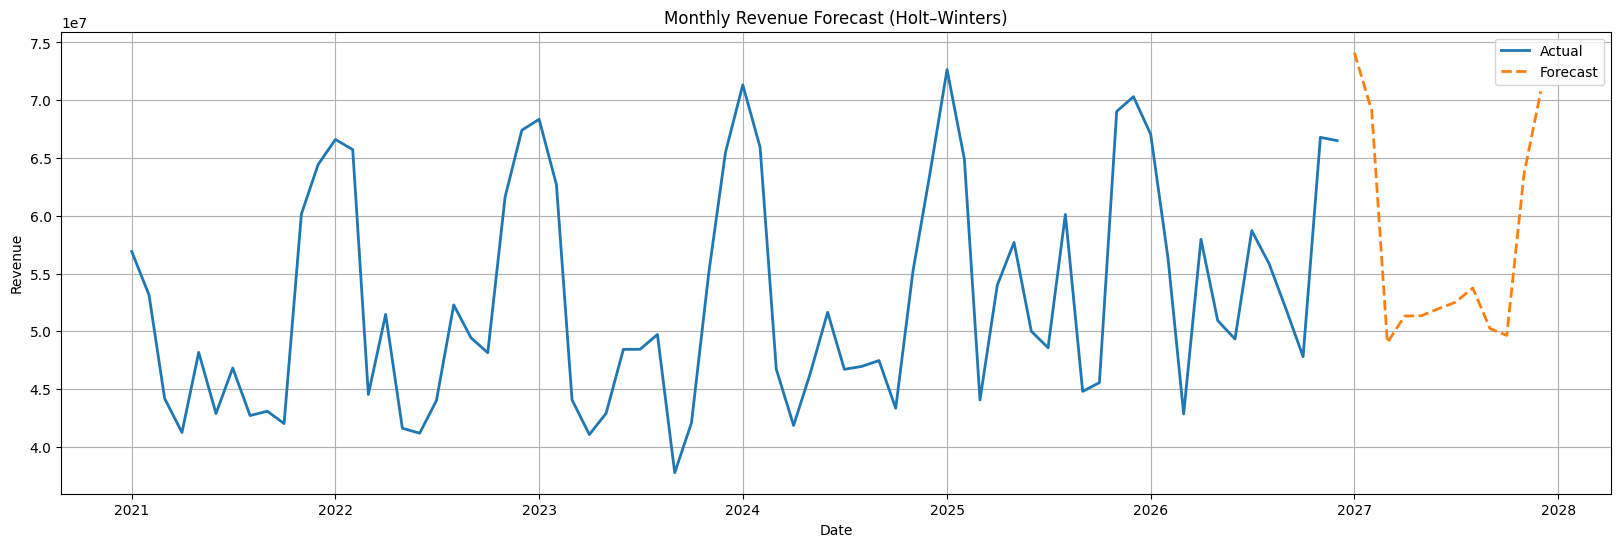

In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing #Holt–Winters (Exponential Smoothing)   forecast
revenue_YM = revenue_YM.asfreq('MS')

model = ExponentialSmoothing(
    revenue_YM,
    trend="add",            # datas have trend
    seasonal="add",         # datas have seasonality
    seasonal_periods=12     # monthly datas
).fit()

# Forecasting 12 months
forecast = model.forecast(12)

# Visualisation of the Holt Winters forecast
plt.figure(figsize=(20,6))
plt.plot(revenue_YM.index, revenue_YM, label="Actual", linewidth=2)
plt.plot(forecast.index, forecast, label="Forecast", linewidth=2, linestyle="--")

plt.title("Monthly Revenue Forecast (Holt–Winters)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend()
plt.show()

In [16]:
MASTER_SALES.to_excel("MASTER_SALES.xlsx",index=False )   # Export the master file